# Exercises week 36

**FYS-STK3155/4155, fall 2026 — deadline Friday September 4 at midnight.**

The aim this week is that you own the two central results of Monday's lecture
— the statistics of the OLS estimator and the bias-variance decomposition,
Eq. (2.47) of the book — and the two resampling tools, the bootstrap and
$k$-fold cross-validation. The code you developed in the Tuesday session
(`week36tuesday.ipynb`) is meant to be reused here, and everything in this set
is directly reusable in Project 1.

Reading: Chapter 2, Sections 2.3–2.12 of the book; Hastie et al., Sections
7.1–7.5, 7.10 and 7.11.

## Exercise 1: Analytical exercises — the statistics of the OLS estimator

Assume the data are generated by the linear model of Eq. (2.37),
$\boldsymbol{y} = \boldsymbol{X}\boldsymbol{\theta} + \boldsymbol{\varepsilon}$,
with independent noise $\varepsilon_i \sim \mathcal{N}(0, \sigma^2)$ and a
fixed (non-stochastic) design matrix $\boldsymbol{X}$ of dimension $n \times p$.

**1a)** Show that the expectation value and variance of a single output are
(Eq. (2.39))

$$
\mathbb{E}[y_i] = \boldsymbol{X}_{i,*}\,\boldsymbol{\theta},
\qquad
\mathrm{Var}(y_i) = \sigma^2 .
$$

**1b)** Show that the OLS estimator is unbiased,
$\mathbb{E}[\hat{\boldsymbol{\theta}}] = \boldsymbol{\theta}$ (Eq. (2.40)), and
derive its variance (Eq. (2.42)),

$$
\mathrm{Var}(\hat{\boldsymbol{\theta}}) = \sigma^2\left(\boldsymbol{X}^T\boldsymbol{X}\right)^{-1}.
$$

*Hint:* use
$\mathbb{E}[\boldsymbol{y}\boldsymbol{y}^T] = \boldsymbol{X}\boldsymbol{\theta}\boldsymbol{\theta}^T\boldsymbol{X}^T + \sigma^2\boldsymbol{I}_{nn}$.

**1c)** Optional: Explain how the diagonal elements of
$\sigma^2(\boldsymbol{X}^T\boldsymbol{X})^{-1}$ give a confidence interval for
the coefficient $\theta_j$ (Eq. (2.43)), and why in practice $\sigma^2$ is
replaced by
$\hat{\sigma}^2 = \|\boldsymbol{y}-\boldsymbol{X}\hat{\boldsymbol{\theta}}\|_2^2/(n-p)$.
Where does the $n-p$ come from? (Think of Bessel's correction, Eq. (2.28).)


## 1(a)

The linear regression model is

$$
\mathbf{y}=\mathbf{X}\boldsymbol{\theta}+\boldsymbol{\varepsilon},
$$

where

$$
\boldsymbol{\theta}
=
\begin{bmatrix}
\theta_1\\
\theta_2\\
\vdots\\
\theta_p
\end{bmatrix},
\qquad
\mathbf{X}_{i,*}
=
\begin{bmatrix}
X_{i1} & X_{i2} & \cdots & X_{ip}
\end{bmatrix}.
$$

For observation $i$,

$$
y_i=\mathbf{X}_{i,*}\boldsymbol{\theta}+\varepsilon_i.
$$

Equivalently,

$$
y_i
=
X_{i1}\theta_1
+
X_{i2}\theta_2
+
\cdots
+
X_{ip}\theta_p
+
\varepsilon_i.
$$

Assume that

$$
\varepsilon_i\sim\mathcal{N}(0,\sigma^2).
$$

Therefore,

$$
\begin{aligned}
\mathbb{E}[y_i]
&=
\mathbb{E}
\left[
\mathbf{X}_{i,*}\boldsymbol{\theta}
+
\varepsilon_i
\right]\\
&=
\mathbf{X}_{i,*}\boldsymbol{\theta}
+
\mathbb{E}[\varepsilon_i]\\
&=
\mathbf{X}_{i,*}\boldsymbol{\theta}.
\end{aligned}
$$

Since $\mathbf{X}_{i,*}\boldsymbol{\theta}$ is fixed,

$$
\begin{aligned}
\operatorname{Var}(y_i)
&=
\operatorname{Var}
\left(
\mathbf{X}_{i,*}\boldsymbol{\theta}
+
\varepsilon_i
\right)\\
&=
\operatorname{Var}
\left(
\mathbf{X}_{i,*}\boldsymbol{\theta}
\right)
+
\operatorname{Var}(\varepsilon_i)\\
&=
0+\sigma^2\\
&=
\sigma^2.
\end{aligned}
$$

Hence,

$$
\boxed{
\mathbb{E}[y_i]
=
\mathbf{X}_{i,*}\boldsymbol{\theta}
}
$$

and

$$
\boxed{
\operatorname{Var}(y_i)=\sigma^2
}
$$

Therefore,

$$
\boxed{
y_i\sim
\mathcal{N}
\left(
\mathbf{X}_{i,*}\boldsymbol{\theta},
\sigma^2
\right)
}
$$







## 1(b)

The ordinary least-squares estimator is

$$
\widehat{\boldsymbol{\theta}}
=
\left(
\mathbf{X}^{T}\mathbf{X}
\right)^{-1}
\mathbf{X}^{T}\mathbf{y}.
$$

Using

$$
\mathbf{y}
=
\mathbf{X}\boldsymbol{\theta}
+
\boldsymbol{\varepsilon},
$$

we obtain

$$
\begin{aligned}
\widehat{\boldsymbol{\theta}}
&=
\left(
\mathbf{X}^{T}\mathbf{X}
\right)^{-1}
\mathbf{X}^{T}
\left(
\mathbf{X}\boldsymbol{\theta}
+
\boldsymbol{\varepsilon}
\right)\\
&=
\left(
\mathbf{X}^{T}\mathbf{X}
\right)^{-1}
\mathbf{X}^{T}\mathbf{X}\boldsymbol{\theta}
+
\left(
\mathbf{X}^{T}\mathbf{X}
\right)^{-1}
\mathbf{X}^{T}\boldsymbol{\varepsilon}.
\end{aligned}
$$

Since

$$
\left(
\mathbf{X}^{T}\mathbf{X}
\right)^{-1}
\left(
\mathbf{X}^{T}\mathbf{X}
\right)
=
\mathbf{I},
$$

we have

$$
\widehat{\boldsymbol{\theta}}
=
\boldsymbol{\theta}
+
\left(
\mathbf{X}^{T}\mathbf{X}
\right)^{-1}
\mathbf{X}^{T}\boldsymbol{\varepsilon}.
$$

Taking the expectation gives

$$
\begin{aligned}
\mathbb{E}
\left[
\widehat{\boldsymbol{\theta}}
\right]
&=
\mathbb{E}
\left[
\boldsymbol{\theta}
+
\left(
\mathbf{X}^{T}\mathbf{X}
\right)^{-1}
\mathbf{X}^{T}\boldsymbol{\varepsilon}
\right]\\
&=
\boldsymbol{\theta}
+
\left(
\mathbf{X}^{T}\mathbf{X}
\right)^{-1}
\mathbf{X}^{T}
\mathbb{E}
\left[
\boldsymbol{\varepsilon}
\right].
\end{aligned}
$$

Because

$$
\mathbb{E}
\left[
\boldsymbol{\varepsilon}
\right]
=
\mathbf{0},
$$

it follows that

$$
\boxed{
\mathbb{E}
\left[
\widehat{\boldsymbol{\theta}}
\right]
=
\boldsymbol{\theta}
}
$$

Thus, the OLS estimator is unbiased.

For the covariance matrix, define

$$
\mathbf{A}
=
\left(
\mathbf{X}^{T}\mathbf{X}
\right)^{-1}
\mathbf{X}^{T}.
$$

Then

$$
\widehat{\boldsymbol{\theta}}
=
\boldsymbol{\theta}
+
\mathbf{A}\boldsymbol{\varepsilon}.
$$

Since $\boldsymbol{\theta}$ is fixed,

$$
\operatorname{Var}
\left(
\widehat{\boldsymbol{\theta}}
\right)
=
\operatorname{Var}
\left(
\mathbf{A}\boldsymbol{\varepsilon}
\right).
$$

Using

$$
\operatorname{Var}(\mathbf{A}\mathbf{z})
=
\mathbf{A}\operatorname{Var}(\mathbf{z})\mathbf{A}^{T},
$$

we obtain

$$
\operatorname{Var}
\left(
\widehat{\boldsymbol{\theta}}
\right)
=
\mathbf{A}
\operatorname{Var}
\left(
\boldsymbol{\varepsilon}
\right)
\mathbf{A}^{T}.
$$

Since

$$
\operatorname{Var}
\left(
\boldsymbol{\varepsilon}
\right)
=
\sigma^2\mathbf{I},
$$

we have

$$
\begin{aligned}
\operatorname{Var}
\left(
\widehat{\boldsymbol{\theta}}
\right)
&=
\left(
\mathbf{X}^{T}\mathbf{X}
\right)^{-1}
\mathbf{X}^{T}
\left(
\sigma^2\mathbf{I}
\right)
\mathbf{X}
\left(
\mathbf{X}^{T}\mathbf{X}
\right)^{-1}\\
&=
\sigma^2
\left(
\mathbf{X}^{T}\mathbf{X}
\right)^{-1}
\mathbf{X}^{T}\mathbf{X}
\left(
\mathbf{X}^{T}\mathbf{X}
\right)^{-1}\\
&=
\sigma^2
\left(
\mathbf{X}^{T}\mathbf{X}
\right)^{-1}.
\end{aligned}
$$

Therefore,

$$
\boxed{
\operatorname{Var}
\left(
\widehat{\boldsymbol{\theta}}
\right)
=
\sigma^2
\left(
\mathbf{X}^{T}\mathbf{X}
\right)^{-1}
}
$$


## Exercise 2: Analytical exercises — deriving the bias-variance tradeoff

Assume now, as in Section 2.10, that the true data are generated by
$\boldsymbol{y} = f(\boldsymbol{x}) + \boldsymbol{\varepsilon}$ with
$\boldsymbol{\varepsilon} \sim \mathcal{N}(0, \sigma^2)$ (Eq. (2.44)), and let
$\tilde{\boldsymbol{y}}$ be the prediction of a model fitted on a randomly
drawn training set.

**2a)** Starting from the expected squared error
$\mathbb{E}[(\boldsymbol{y}-\tilde{\boldsymbol{y}})^2]$ and adding and
subtracting $\mathbb{E}[\tilde{\boldsymbol{y}}]$, derive the decomposition of
Eq. (2.47),

$$
\mathbb{E}\left[(\boldsymbol{y}-\tilde{\boldsymbol{y}})^2\right]
= \frac{1}{n}\sum_i\left(f_i-\mathbb{E}[\tilde{\boldsymbol{y}}]\right)^2
+ \frac{1}{n}\sum_i\left(\tilde{y}_i-\mathbb{E}[\tilde{\boldsymbol{y}}]\right)^2
+ \sigma^2 .
$$

Show explicitly that all three cross terms vanish, stating for each one which
assumption kills it (zero-mean noise, independence of noise and training set,
$f$ non-stochastic).

**2b)** Explain in your own words what the expectation
$\mathbb{E}[\cdot]$ runs over, and what each of the three terms means for the
polynomial-fit example of the lecture.

**2c)** In the numerical estimate (Tuesday's Case 1) the bias is computed
against $y_{\mathrm{test}}$ rather than the unknown $f$. Show that the
measured "bias" then contains $\sigma^2$, so the printed identity
`error >= bias + variance` is an inequality.

## 2a 

we consider

$$
m_i=\mathbb{E}[\widetilde y_i].
$$

Using $y_i=f_i+\varepsilon_i$, and adding and subtracting $m_i$,

$$
y_i-\widetilde y_i
=
(f_i-m_i)+(m_i-\widetilde y_i)+\varepsilon_i.
$$

Squaring this expression gives

$$
\begin{aligned}
(y_i-\widetilde y_i)^2
={}&(f_i-m_i)^2+(m_i-\widetilde y_i)^2+\varepsilon_i^2\\
&+2(f_i-m_i)(m_i-\widetilde y_i)\\
&+2(f_i-m_i)\varepsilon_i\\
&+2(m_i-\widetilde y_i)\varepsilon_i.
\end{aligned}
$$

The first cross term is zero because

$$
\mathbb{E}[m_i-\widetilde y_i]
=
m_i-\mathbb{E}[\widetilde y_i]
=0.
$$

The second cross term is zero because the noise has zero mean:

$$
\mathbb{E}[\varepsilon_i]=0.
$$

The third cross term is zero because the test noise is independent of the
training set and the fitted prediction:

$$
\mathbb{E}[(m_i-\widetilde y_i)\varepsilon_i]
=
\mathbb{E}[m_i-\widetilde y_i]\,
\mathbb{E}[\varepsilon_i]
=0.
$$

Also,

$$
\mathbb{E}[\varepsilon_i^2]=\sigma^2.
$$

Therefore,

$$
\boxed{
\mathbb{E}[(y-\widetilde y)^2]
=
\frac{1}{n}\sum_i
\left(f_i-\mathbb{E}[\widetilde y_i]\right)^2
+
\frac{1}{n}\sum_i
\mathbb{E}\left[
\left(\widetilde y_i-\mathbb{E}[\widetilde y_i]\right)^2
\right]
+
\sigma^2
}
$$


The three cross terms vanish as follows:

$$
\mathbb{E}\left[
2(f_i-m_i)(m_i-\widetilde y_i)
\right]
=
2(f_i-m_i)
\left(m_i-\mathbb{E}[\widetilde y_i]\right)
=0.
$$

Here, $f_i$ is non-stochastic, and $m_i=\mathbb{E}[\widetilde y_i]$.

$$
\mathbb{E}\left[
2(f_i-m_i)\varepsilon_i
\right]
=
2(f_i-m_i)\mathbb{E}[\varepsilon_i]
=0.
$$

This follows from the zero-mean noise assumption,
$\mathbb{E}[\varepsilon_i]=0$.

$$
\mathbb{E}\left[
2(m_i-\widetilde y_i)\varepsilon_i
\right]
=
2\mathbb{E}[m_i-\widetilde y_i]\,
\mathbb{E}[\varepsilon_i]
=0.
$$

This follows because the test noise is independent of the training set and
therefore independent of the fitted prediction $\widetilde y_i$.


## 2b

The expectation $\mathbb{E}[\cdot]$ is taken over different randomly drawn
training sets and the random noise in a new observation. Therefore, fitting
the model repeatedly can produce different predictions $\widetilde y$.

The first term is the squared bias:

$$
\frac{1}{n}\sum_i
\left(f_i-\mathbb{E}[\widetilde y_i]\right)^2.
$$

It measures the difference between the true function and the average
prediction. In the polynomial example, a model with a degree that is too low
is too simple and usually has high bias.

The second term is the variance:

$$
\frac{1}{n}\sum_i
\mathbb{E}\left[
\left(\widetilde y_i-\mathbb{E}[\widetilde y_i]\right)^2
\right].
$$

It measures how much the fitted prediction changes when the training set
changes. High-degree polynomial models are more sensitive to the training
data and usually have higher variance.

The final term, $\sigma^2$, is the irreducible noise in the data. It cannot be
removed by choosing a different polynomial degree.

## 2c

In the code, the bias is calculated using $y_{\mathrm{test}}$ instead of the
true function $f$. Since

$$
y_{\mathrm{test}}=f+\varepsilon,
$$

we have

$$
\begin{aligned}
\mathbb{E}\left[
\left(y_{\mathrm{test}}-\mathbb{E}[\widetilde y]\right)^2
\right]
&=
\mathbb{E}\left[
\left(f-\mathbb{E}[\widetilde y]+\varepsilon\right)^2
\right]
\\
&=
\left(f-\mathbb{E}[\widetilde y]\right)^2+\sigma^2.
\end{aligned}
$$

The cross term is zero because the noise has zero mean. Therefore, the
measured bias contains both the true squared bias and the noise:

$$
\text{measured bias}=\text{bias}^2+\sigma^2.
$$

This is why the numerical decomposition is written as

$$
\text{error}\approx\text{measured bias}+\text{variance}.
$$

## Exercise 3: The bias-variance tradeoff with the bootstrap

We use the same data as in the Tuesday session (and as in last week's
exercise 3),

$$
y = e^{-x^2} + 1.5\,e^{-(x-2)^2} + \varepsilon,
\qquad \varepsilon \sim \mathcal{N}(0, 0.1^2),
$$

on $x \in [-3, 3]$.

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.utils import resample

np.random.seed(2026)
n = 40
n_bootstraps , maxdegree = 100, 14
x = np.linspace(-3, 3, n).reshape(-1, 1)
y = np.exp(-x**2) + 1.5 * np.exp(-(x - 2)**2) + np.random.normal(0, 0.1, x.shape)

1. Split the data in training and test parts (80/20). For polynomial degrees
   $0$ to $13$, use the bootstrap (100 resamples of the training data) to
   estimate the test error, the squared bias and the variance, and plot the
   three curves as functions of the degree (compare with
   `week36_bias_variance.pdf` from the lecture — with seed 2026 you should
   reproduce it).
2. Discuss the figure in terms of Eq. (2.47): where is the model dominated by
   bias, where by variance, and where would you place the optimal degree?
3. Repeat the analysis for $n = 100$ and $n = 400$ data points and comment on
   how the curves and the optimal degree move.
4. Replace OLS by Ridge regression at a fixed high degree (say 12) and study
   the three terms as functions of $\lambda$ (for example
   `np.logspace(-6, 2, 9)`). Which term does $\lambda$ attack, and at what
   cost?

## 3.1

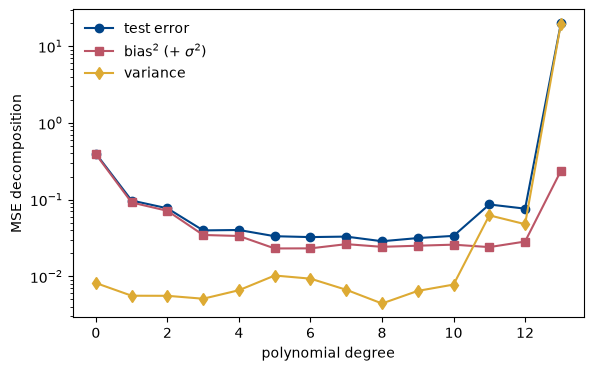

In [22]:
# Got help from week36tuesday.ipynb

#here we split the data into training and testing sets, with 20% of the data used for testing
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2,random_state=2026)


#this is an array to store for each degree the error, bias and variance
error = np.zeros(maxdegree)
bias = np.zeros(maxdegree)
variance = np.zeros(maxdegree)

#making a loop to iterate through each degree of polynomial from 0 to maxdegree-1
for degree in range(maxdegree):
    #creating polynomial ols model
    model= make_pipeline(PolynomialFeatures(degree= degree),
                          LinearRegression(fit_intercept= False))

    y_pred = np.empty((y_test.shape[0], n_bootstraps))

    #bootstrap loop to create n_bootstraps resampled training sets and fit the model
    for i in range(n_bootstraps):
        x , y = resample(x_train, y_train)

        #fitting the model and predicting test set
        y_pred[:, i] = model.fit(x, y).predict(x_test).ravel()


    error[degree] = np.mean(np.mean((y_test - y_pred)**2, axis=1, keepdims=True))
    bias[degree] = np.mean((y_test - np.mean(y_pred, axis=1, keepdims=True))**2)
    variance[degree] = np.mean(np.var(y_pred, axis=1, keepdims=True))



BLUE, RED, YELLOW = "#004488", "#BB5566", "#DDAA33" 

fig, ax = plt.subplots(figsize=(6.6, 4.0))
ax.plot(range(maxdegree), error, "o-", color=BLUE, label="test error")
ax.plot(range(maxdegree), bias, "s-", color=RED, label=r"bias$^2$ (+ $\sigma^2$)")
ax.plot(range(maxdegree), variance, "d-", color=YELLOW, label="variance")
ax.set_yscale("log")
ax.set_xlabel("polynomial degree")
ax.set_ylabel("MSE decomposition")
ax.legend(frameon=False)
plt.show()



In [24]:
print(np.argmin(error))

8


## 3.2

At low polynomial degrees, the model is too simple to capture the shape of
the data. Therefore, the squared bias is high and the variance is low. This
is underfitting.

As the polynomial degree increases, the squared bias decreases because the
model becomes more flexible. However, at high degrees, the variance increases
strongly. This means that the model becomes sensitive to small changes in the
training data and starts to overfit.

In this experiment, the minimum test error occurs at degree 8:

$$
d_{\mathrm{optimal}}=\operatorname{argmin}_d\mathrm{Error}(d)=8.
$$

Therefore, I choose degree 8 as the optimal polynomial degree for this data
set. At this degree, the model has a good balance between squared bias and
variance.

## 3.3

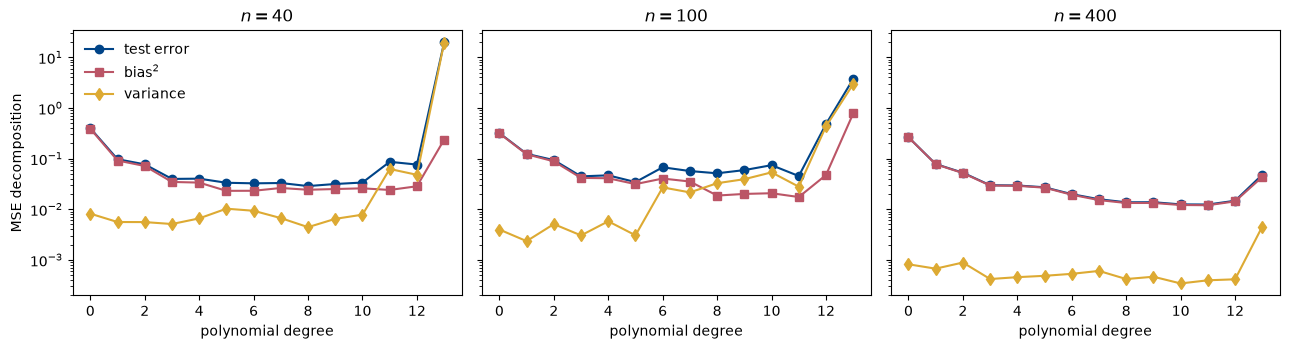

In [26]:
def bias_variance_sweep(n=40, noise=0.1, maxdegree=14, n_bootstraps=100,
                        make_model=None, seed=2026):
    """Bootstrap estimate of error/bias^2/variance vs polynomial degree."""
    if make_model is None:
        make_model = lambda deg: make_pipeline(
            PolynomialFeatures(degree=deg), LinearRegression(fit_intercept=False))
    np.random.seed(seed)
    x = np.linspace(-3, 3, n).reshape(-1, 1)
    y = np.exp(-x**2) + 1.5 * np.exp(-(x - 2)**2) + np.random.normal(0, noise, x.shape)
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2,
                                                        random_state=seed)
    error, bias, variance = (np.zeros(maxdegree) for _ in range(3))
    for degree in range(maxdegree):
        model = make_model(degree)
        y_pred = np.empty((y_test.shape[0], n_bootstraps))
        for i in range(n_bootstraps):
            x_, y_ = resample(x_train, y_train)
            y_pred[:, i] = model.fit(x_, y_).predict(x_test).ravel()
        error[degree] = np.mean(np.mean((y_test - y_pred)**2, axis=1, keepdims=True))
        bias[degree] = np.mean((y_test - np.mean(y_pred, axis=1, keepdims=True))**2)
        variance[degree] = np.mean(np.var(y_pred, axis=1, keepdims=True))
    return error, bias, variance



fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharey=True)
for ax, n_ in zip(axes, (40, 100, 400)):
    err, b2, var = bias_variance_sweep(n=n_)
    ax.plot(range(14), err, "o-", color=BLUE, label="test error")
    ax.plot(range(14), b2, "s-", color=RED, label=r"bias$^2$")
    ax.plot(range(14), var, "d-", color=YELLOW, label="variance")
    ax.set_yscale("log")
    ax.set_title(f"$n = {n_}$")
    ax.set_xlabel("polynomial degree")
axes[0].set_ylabel("MSE decomposition")
axes[0].legend(frameon=False)

plt.tight_layout()
plt.show()

As the number of data points increases, the variance becomes smaller and more
stable across the polynomial degrees. For \(n=40\), the variance increases
strongly at high degrees. For \(n=100\), this increase is smaller, and for
\(n=400\), the variance remains low until approximately degree 12.

The test error also becomes closer to the squared bias because the difference
between them is approximately the variance. Therefore, when the variance
decreases, the two curves become closer.

The minimum test error occurs at degree 8 for \(n=40\), degree 5 for \(n=100\),
and degree 11 for \(n=400\). Although the optimal degree does not increase
regularly because of random noise, more data generally make higher-degree
models more stable.


## 3.4

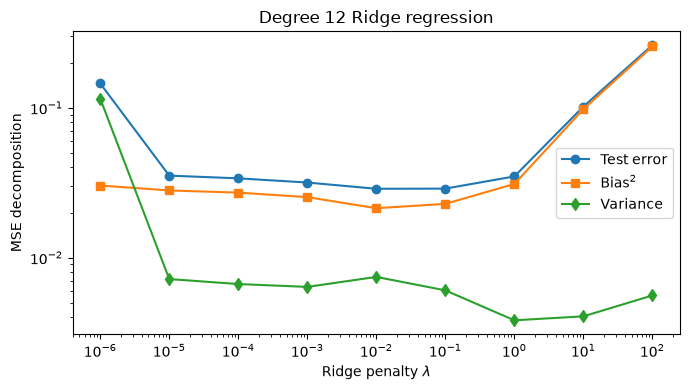

In [31]:
fixed_degree = 12
lams = np.logspace(-6 , 2, 9)

results = []

for lam in lams:
     #We define a function for creating a Ridge model
    def make_ridge(degree, current_lam=lam):
        model = make_pipeline( PolynomialFeatures(degree=degree),
            StandardScaler(),
            Ridge(alpha=current_lam))

        return model
    
    
    error, bias, variance = bias_variance_sweep(n=40, maxdegree=fixed_degree + 1,
                                       n_bootstraps=100, make_model= make_ridge , seed=2026)

   #we save results in results list for each lambda value
    results.append((error[fixed_degree], bias[fixed_degree], variance[fixed_degree]))


#converting list to Numpy array for easier plotting
results = np.array(results)



plt.figure(figsize=(7, 4))

plt.plot(lams, results[:, 0], "o-", label="Test error" )
plt.plot(lams, results[:, 1], "s-", label=r"Bias$^2$")
plt.plot(lams, results[:, 2], "d-", label="Variance")

plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"Ridge penalty $\lambda$")
plt.ylabel("MSE decomposition")
plt.title("Degree 12 Ridge regression")
plt.legend()
plt.tight_layout()
plt.show()


The Ridge penalty mainly attacks the variance. By increasing \(\lambda\),
the coefficients are shrunk and the model becomes less sensitive to changes
in the training data. However, the cost is an increase in squared bias. If
\(\lambda\) becomes too large, the model underfits and the test error increases.
In this experiment, the lowest test error occurs at approximately
\(\lambda=0.01\).

## Exercise 4: Cross-validation

Still with the same type of data, we now select models without consuming a
test set.

1. Use scikit-learn's (or perhaps write your own) $k$-fold cross-validation function: shuffle the data,
   split into $k$ folds, use each fold as test set once, and return the mean
   and standard deviation over folds of the test MSE. Do **not** use
   `cross_val_score` inside your own function.
2. Use it with $k = 5$ to compute the CV estimate of the MSE for OLS with
   polynomial degrees $0$ to $13$, and compare with the bootstrap analysis of
   exercise 3: do the two methods point to the same degree window?
3. For a degree-6 polynomial with Ridge regression on
   $y = 3x^2 + \varepsilon$, $\varepsilon \sim \mathcal{N}(0,1)$, $n=100$
   (Tuesday's Case 2), compute the CV MSE on
   `np.logspace(-3, 5, 100)` and find the optimal $\lambda$. Any
   scaling/preprocessing must be fitted **inside** each fold — explain in one
   or two sentences why.
4. Try $k = 5, 10$ and $n$ (leave-one-out). Comment on the stability of the
   selected $\lambda$ and on the computational cost.

## 4.1

In [42]:
from sklearn import clone

def kfold_mse(model, x, y, k=5, seed=2026):
    kfold= KFold(n_splits=k, shuffle=True, random_state=seed)
    
    fold_mse = np.zeros(k)   #we store MSE for each fold

    for j , (train_inds, test_inds) in enumerate(kfold.split(x)):
        x_train, y_train = x[train_inds], y[train_inds]
        x_test, y_test = x[test_inds], y[test_inds]

        #we clone and fit the model 
        model_clone = clone(model)
        model_clone.fit(x_train, y_train)

        y_pred = model_clone.predict(x_test)    # predicting the test set
        fold_mse[j] = np.mean((y_test - y_pred)**2) #finding the MSE for each fold

    return fold_mse.mean() , fold_mse.std()  #returning the mean and std of MSE across folds

## 4.2

In [43]:
np.random.seed(2026)
n=40 

x_poly = np.linspace(-3, 3, n).reshape(-1, 1)
y_poly = (
    np.exp(-x_poly**2)
    + 1.5 * np.exp(-(x_poly - 2)**2)
    + np.random.normal(0, 0.1, x_poly.shape)
).ravel()

max_degrees= 14 #degrees start from 0 to 13

cv_mse= np.zeros(max_degrees)
cv_std= np.zeros(max_degrees)    #storeing the std and mean of cv MSE

for degree in range(max_degrees):
    model = make_pipeline(PolynomialFeatures(degree=degree),
                           LinearRegression(fit_intercept=False))   
    #created a polynomial regression model for each degree
    
    cv_mse[degree], cv_std[degree] = kfold_mse(model= model, x=x_poly, y= y_poly, k=5, seed=2026)

    #smallest MSE degree
best_degree = np.argmin(cv_mse)


print("Best polinomial degree based on 5-fold cross-validation MSE is:", best_degree)
print("Minimum CV MSE:", cv_mse[best_degree])
print("Standard deviation:", cv_std[best_degree])

# Print the result for every degree
print(f"\n{'Degree':>8} {'Mean MSE':>12} {'Std MSE':>12}")

for degree in range(max_degrees):
    print(f"{degree:>8} {cv_mse[degree]:>12.4f} {cv_std[degree]:>12.4f}")


Best polinomial degree based on 5-fold cross-validation MSE is: 9
Minimum CV MSE: 0.019757412028534087
Standard deviation: 0.011870042199031943

  Degree     Mean MSE      Std MSE
       0       0.2992       0.1187
       1       0.1263       0.1181
       2       0.1245       0.1024
       3       0.0684       0.0384
       4       0.0913       0.0774
       5       0.0508       0.0211
       6       0.1868       0.3054
       7       0.2515       0.4218
       8       0.0336       0.0266
       9       0.0198       0.0119
      10       0.5708       1.0811
      11       3.8891       7.7258
      12       2.9347       5.7482
      13      53.7697     105.0343


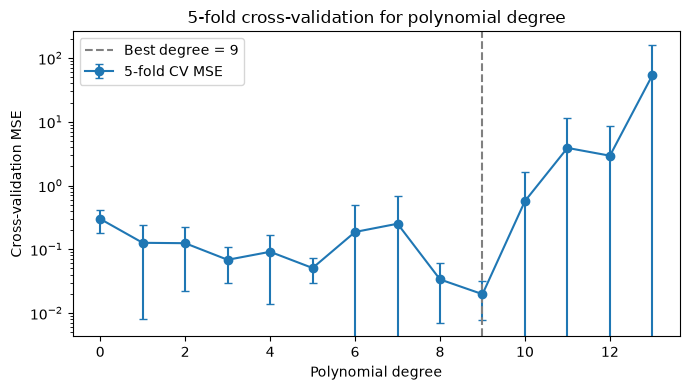

In [40]:
plt.figure(figsize=(7, 4))  #plotting the mean and std of MSE for each degree


plt.errorbar( range(max_degrees) , cv_mse, yerr=cv_std, marker="o", capsize=3, label="5-fold CV MSE" )
plt.axvline( best_degree, color="gray", linestyle="--", 
            label=f"Best degree = {best_degree}" ) #line for the best degree which is 9


plt.yscale("log")
plt.xlabel("Polynomial degree")
plt.ylabel("Cross-validation MSE")
plt.title("5-fold cross-validation for polynomial degree")
plt.legend()
plt.tight_layout()
plt.show()

The 5-fold cross-validation gives the minimum mean MSE at polynomial degree 9.
The error bars show the standard deviation of the MSE values across the five
folds. Larger error bars mean that the model performance changes more between
the folds and is therefore less stable.

In the bootstrap analysis, the minimum test error occurred at degree 8, with
a broad low-error region around degrees 5 to 9. Therefore, cross-validation
and bootstrap do not select exactly the same degree, but they point to the
same intermediate degree window. Both results show that low degrees are too
simple, while very high degrees give large and unstable prediction errors.

## 4.3

In [48]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold
from sklearn.base import clone
from sklearn.pipeline import make_pipeline

In [59]:
rng = np.random.default_rng(seed=2026)
n=100

noise= rng.standard_normal(n) 
x_ridge = rng.standard_normal(n)
y_ridge = 3* x_ridge**2 + noise

x_ridge = x_ridge.reshape(-1, 1)  #reshaping the data to be 2D for sklearn

#creating lambda values to test
lambdas = np.logspace(-3, 5, 100)

ridge_cv_mse = np.zeros(len(lambdas))  #array to store the mean, and std of MSE for each lambda
ridge_cv_std = np.zeros(len(lambdas))  

#testing each lambda
for i, lam in enumerate(lambdas):

    model= make_pipeline(PolynomialFeatures(degree=2), StandardScaler(), Ridge(alpha=lam))

    ridge_cv_mse[i], ridge_cv_std[i]= kfold_mse(model=model, x=x_ridge, y=y_ridge, k=5, seed=2026)


#we find the best lambda value which gives the minimum MSE
best_index= np.argmin(ridge_cv_mse)
best_lambda= lambdas[best_index]
best_mse= ridge_cv_mse[best_index]
best_std= ridge_cv_std[best_index]

print("Optimal lambda:", best_lambda)
print("Minimum CV MSE:", best_mse)
print("Standard deviation:", best_std)


Optimal lambda: 0.5590810182512228
Minimum CV MSE: 1.0560871567269925
Standard deviation: 0.4230432607231578


The preprocessing is fitted only on the training data within each fold and then applied to the validation data. Fitting it on the entire dataset would allow information from the validation fold to influence the model, causing data leakage and an overly optimistic CV error.

## 4.4

In [62]:
k_values = [5, 10, n]

best_lambda = np.zeros(len(k_values))
best_mse = np.zeros(len(k_values))
all_cv_mse = np.zeros((len(k_values), len(lambdas)))

for i, k_value in enumerate(k_values):

    for j, lam in enumerate(lambdas):

        model= make_pipeline(PolynomialFeatures(degree=6),
                              StandardScaler(), Ridge(alpha=lam))

        mean_mse, std_mse = kfold_mse(
            model=model,
            x=x_ridge,
            y=y_ridge,
            k=k_value,
            seed=2026
        )

        all_cv_mse[i, j] = mean_mse
           

    best_index = np.argmin(all_cv_mse[i])

    best_lambda[i] = lambdas[best_index]
    best_mse[i] = all_cv_mse[i, best_index]

    print(
        f"k = {k_value:3d}: "
        f"best lambda = {best_lambda[i]:.4g}, "
        f"CV MSE = {best_mse[i]:.4f}"
    )

k =   5: best lambda = 0.977, CV MSE = 1.1695
k =  10: best lambda = 1.177, CV MSE = 1.2149
k = 100: best lambda = 1.177, CV MSE = 1.2328


 The selected \(\lambda\) is stable because the optimal values are very close: \(0.977\) for \(k=5\) and \(1.177\) for both \(k=10\) and LOOCV. This means that changing the number of folds does not significantly change the selected Ridge penalty. However, the computational cost increases as \(k\) increases. LOOCV is the most expensive because the model must be trained 100 times for each value of \(\lambda\), while 5-fold CV requires only 5 training runs. In this case, 10-fold CV and LOOCV select the same \(\lambda\), so the additional cost of LOOCV does not improve the selection.


## Exercise 5 (optional): error bars from the bootstrap

Use the bootstrap to attach uncertainties to fitted parameters, where the
analytical formula of exercise 1 can be checked — and where it cannot.

1. For OLS on a degree-3 polynomial fit of the exercise-3 data, bootstrap the
   training data 1000 times and histogram the resulting
   $\hat{\theta}_j^*$. Compare the bootstrap standard deviations with the
   analytical standard errors
   $\hat{\sigma}\sqrt{[(\boldsymbol{X}^T\boldsymbol{X})^{-1}]_{jj}}$ of
   Eq. (2.43).
2. Repeat for Lasso with a small penalty. Why is the bootstrap now the only
   option on the table? (Which assumption behind Eq. (2.43) fails?)

In [16]:
# Your code for exercise 5 here

### Practicalities

Deliver your solutions (a single Jupyter notebook, with the analytical parts
either typeset in Markdown/LaTeX or as a scanned handwritten note) in Canvas
before **Friday September 4 at midnight**. Collaboration is encouraged — list
your collaborators.